# Ví dụ 2 — Multiclass Hinge Loss (Primal) + GD **ĐÃ SỬA/NÂNG CẤP**
Giữ nguyên dữ liệu; thêm theo dõi loss/acc và hiển thị ổn định.

## Import

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Dữ liệu

In [ ]:
np.random.seed(0)
n_per_class=100
means=np.array([[0.,0.],[3.,3.],[0.,4.]])
cov=np.array([[0.4,0.],[0.,0.4]])
X_list,y_list=[],[]
for k,mu in enumerate(means):
    Xk=np.random.multivariate_normal(mu,cov,n_per_class)
    yk=np.full(n_per_class,k,int)
    X_list.append(Xk); y_list.append(yk)
X=np.vstack(X_list); y=np.concatenate(y_list)
n,d=X.shape; K=len(np.unique(y))

## Huấn luyện

In [ ]:
def train_multiclass_svm_hinge_sum(
    X, y, K,
    lr=0.5, lam=0.01, epochs=300,
    use_bias=True, shuffle=True, verbose=True
):
    n, d0 = X.shape
    Xb = np.hstack([X, np.ones((n,1))]) if use_bias else X
    n, d = Xb.shape

    W = 0.001 * np.random.randn(K, d)  # tránh symmetry/collapse khi init 0

    hist = {"loss": [], "acc": []}

    for ep in range(1, epochs + 1):
        idxs = np.random.permutation(n) if shuffle else np.arange(n)

        grad = lam * W
        hinge_sum = 0.0

        for i in idxs:
            xi = Xb[i]
            yi = y[i]
            scores = xi @ W.T

            margins = scores - scores[yi] + 1.0
            margins[yi] = 0.0

            viol = np.where(margins > 0)[0]  # all violating classes
            if viol.size > 0:
                hinge_sum += margins[viol].sum()
                grad[yi] -= viol.size * xi
                grad[viol] += xi  # broadcast add to each violating row

        grad /= n  # IMPORTANT: average

        W -= lr * grad

        pred = np.argmax(Xb @ W.T, axis=1)
        acc = (pred == y).mean()
        loss = 0.5 * lam * np.sum(W*W) + (hinge_sum / n)

        hist["loss"].append(loss)
        hist["acc"].append(acc)

        if verbose and (ep == 1 or ep % 20 == 0):
            print(f"Epoch {ep:4d}: loss={loss:.4f} acc={acc:.4f} hinge={hinge_sum/n:.4f}")

    return W, hist, Xb


## Đánh giá & vẽ

Epoch    1: loss=2.0196 acc=0.7633 hinge=2.0024
Epoch   20: loss=0.0788 acc=0.9900 hinge=0.0540
Epoch   40: loss=0.0742 acc=0.9900 hinge=0.0418
Epoch   60: loss=0.0749 acc=0.9933 hinge=0.0376
Epoch   80: loss=0.0763 acc=0.9933 hinge=0.0338
Epoch  100: loss=0.0780 acc=0.9933 hinge=0.0302
Epoch  120: loss=0.0808 acc=0.9933 hinge=0.0277
Epoch  140: loss=0.0825 acc=0.9933 hinge=0.0250
Epoch  160: loss=0.0851 acc=0.9933 hinge=0.0230
Epoch  180: loss=0.0879 acc=0.9900 hinge=0.0211
Epoch  200: loss=0.0908 acc=0.9933 hinge=0.0193
Epoch  220: loss=0.0938 acc=0.9900 hinge=0.0179
Epoch  240: loss=0.0965 acc=0.9900 hinge=0.0169
Epoch  260: loss=0.0990 acc=0.9900 hinge=0.0163
Epoch  280: loss=0.1014 acc=0.9900 hinge=0.0157
Epoch  300: loss=0.1038 acc=0.9900 hinge=0.0152
Acc: 0.99
[[100   0   0]
 [  0  98   2]
 [  0   1  99]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     0.9899    0.9800    0.9849       100
           2 

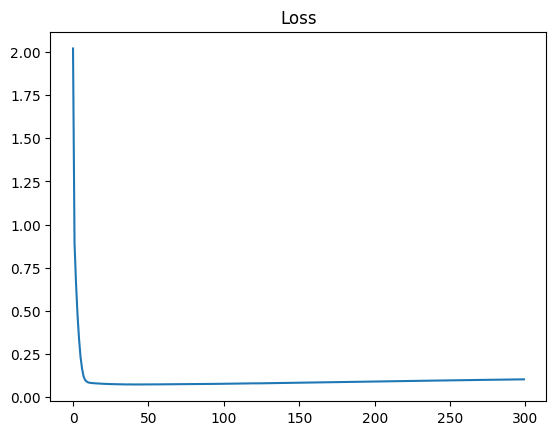

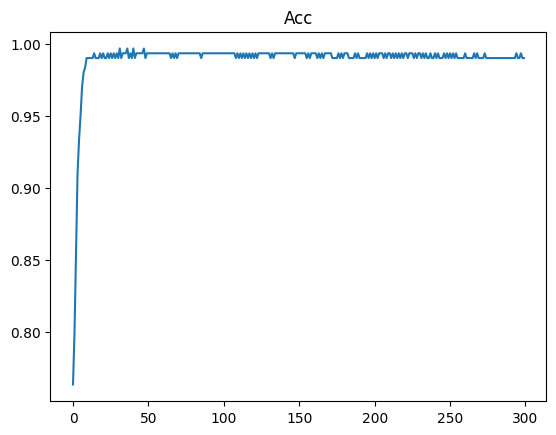

NameError: name 'xx' is not defined

In [ ]:
W, hist, Xb = train_multiclass_svm_hinge_sum(X, y, K)

y_pred = np.argmax(Xb @ W.T, axis=1)
print("Acc:", accuracy_score(y, y_pred))
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred, digits=4))


plt.figure(); plt.plot(hist['loss']); plt.title("Loss"); plt.show()
plt.figure(); plt.plot(hist['acc']); plt.title("Acc"); plt.show()

grid = np.c_[xx.ravel(), yy.ravel()]                 # (N,2)
gridb = np.hstack([grid, np.ones((grid.shape[0],1))]) # (N,3)  <-- thêm bias
Z = np.argmax(gridb @ W.T, axis=1).reshape(xx.shape)


plt.figure(figsize=(6.5,5.5))
plt.contourf(xx, yy, Z, alpha=0.25)

for k in range(K):
    plt.scatter(X[y==k,0], X[y==k,1], label=f"Class {k}", alpha=0.8)

plt.legend()
plt.grid(True)
plt.show()

